### 匯入套件與資料集下載
此區塊負責初始化的準備工作。
程式會執行以下步驟：
1.  **匯入函式庫**：包含數值運算 (NumPy)、影像處理 (PIL, Matplotlib) 與 PyTorch 深度學習工具。
2.  **裝置檢查**：系統自動偵測並設定運算裝置（優先使用 GPU）。
3.  **資料下載**：檢查目錄中是否已存在 `raccoon_dataset`，若無則從 GitHub 下載並驗證目錄結構。

In [2]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import os
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. 檢查運算裝置 (CPU or GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 2. 下載 Raccoon Dataset
# 如果資料夾不存在，才執行下載指令，避免重複下載
if not os.path.exists("raccoon_dataset"):
    print("Downloading Raccoon Dataset...")
    # 使用系統指令 git clone 下載資料集
    os.system("git clone https://github.com/experiencor/raccoon_dataset.git")
    print("Download complete.")
else:
    print("Raccoon Dataset already exists.")

# 3. 簡單檢查目錄結構
# 確認 annotations (存放 XML) 與 images (存放 JPG) 資料夾是否存在
if os.path.exists("raccoon_dataset/annotations") and os.path.exists("raccoon_dataset/images"):
    print("Check: Dataset folders found. (XML and Images are ready)")
else:
    print("Warning: Dataset structure seems incorrect!")

Using device: cuda


Cloning into 'raccoon_dataset'...


Download complete.
Check: Dataset folders found. (XML and Images are ready)


### 定義資料集類別 (Dataset Class)
定義 `RaccoonDataset` 類別，繼承自 PyTorch 的 Dataset。
此類別的主要功能包括：
* **讀取路徑**：自動對應圖片與 XML 標註檔。
* **解析 XML**：提取邊界框 (Bounding Box) 座標與類別標籤。
* **資料轉換**：整合 `Albumentations` 進行資料增強，並將圖片與標註轉換為模型可接受的 Tensor 格式。

In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from PIL import Image
import os
import xml.etree.ElementTree as ET
import albumentations as A
from albumentations.pytorch import ToTensorV2

class RaccoonDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # 設定資料路徑
        self.img_dir = os.path.join(root_dir, 'images')
        self.xml_dir = os.path.join(root_dir, 'annotations')

        # 讀取所有 XML 檔案列表並排序，確保索引一致
        # 過濾非 xml 的檔案以防萬一
        self.xml_list = sorted([f for f in os.listdir(self.xml_dir) if f.endswith('.xml')])

        # 定義類別對應表
        self.class_to_id = {'raccoon': 1}

    def __len__(self):
        # 回傳資料集總筆數
        return len(self.xml_list)

    def __getitem__(self, idx):
        # 1. 根據索引取得 XML 檔案路徑
        xml_file = self.xml_list[idx]
        xml_path = os.path.join(self.xml_dir, xml_file)

        # 2. 解析 XML
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # 3. 找出對應的圖片檔名並讀取
        img_name = xml_file.replace('.xml', '.jpg')
        img_path = os.path.join(self.img_dir, img_name)

        # 將圖片轉為 RGB，避免 RGBA 或灰階導致 Tensor 維度不一致
        img = Image.open(img_path).convert("RGB")
        img = np.array(img)

        # 4. 提取 Bounding Box 資訊
        boxes = []
        labels = []

        # 遍歷 XML 中所有的 <object>
        for obj in root.findall('object'):
            name = obj.find('name').text

            # 如果類別不在我們的清單中，就跳過
            if name not in self.class_to_id:
                continue

            label = self.class_to_id[name]

            # 讀取座標 (Pascal VOC 格式: xmin, ymin, xmax, ymax)
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        # 5. 執行資料增強
        if self.transforms:
            # 將圖片、框框、標籤一起丟進去轉換
            transformed = self.transforms(image=img, bboxes=boxes, class_labels=labels)
            
            # 取出轉換後的結果
            img = transformed['image']       # 這是已經變 Tensor 的圖片 
            boxes = transformed['bboxes']      # 這是變形後的座標 List
            labels = transformed['class_labels'] # 這是對應的標籤 List

        # 系統強制轉型與歸一化
        # 若是 uint8 Tensor，程式將其轉成 float 並除以 255
        if isinstance(img, torch.Tensor) and img.dtype == torch.uint8:
            img = img.float() / 255.0
            
        # 6. 程式轉換為 Tensor 並計算 COCO 格式資訊
        # box 座標轉為 FloatTensor，標籤轉為 Int64Tensor
        boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
        labels_tensor = torch.as_tensor(labels, dtype=torch.int64)

        # 特殊情況處理：如果裁切後，圖片裡沒有浣熊了 (boxes 為空)
        if len(boxes_tensor) == 0:
            # 給空 Tensor (0, 4)，避免 DataLoader 報錯
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            
        # 程式建立 image_id
        image_id = torch.tensor([idx])

        # 程式計算 area，必須使用轉換後的 boxes_tensor
        if len(boxes_tensor) > 0:
            area = (boxes_tensor[:, 3] - boxes_tensor[:, 1]) * (boxes_tensor[:, 2] - boxes_tensor[:, 0])
        else:
            area = torch.as_tensor([], dtype=torch.float32)
            
        # 建立 iscrowd
        num_objs = len(boxes_tensor)
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # 7. 包裝 Target 字典
        target = {}
        target["boxes"] = boxes_tensor
        target["labels"] = labels_tensor
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        return img, target

print("RaccoonDataset 類別定義完成。")

RaccoonDataset 類別定義完成。


### 資料增強策略與 DataLoader 建立
此區塊設定了訓練集與測試集的資料前處理策略。
* **訓練集 (Train)**：採用幾何變換（翻轉、旋轉）、雜訊、模糊與光影變化等增強技術，提升模型泛化能力。
* **測試集 (Test)**：僅進行標準化與 Tensor 轉換。
最後，程式將資料集以 80/20 比例切分，並建立 DataLoader 以便批次讀取。

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import DataLoader, Subset

# 1. 定義訓練集增強策略
def get_train_transform():
    return A.Compose([
        # 幾何變換 
        A.HorizontalFlip(p=0.5), # 程式執行水平翻轉
        # 程式執行旋轉與縮放
        A.Affine(
                translate_percent={'x': (-0.0625, 0.0625), 'y': (-0.0625, 0.0625)},
                scale=(0.9, 1.1),
                rotate=(-15, 15),
                p=0.5
                ),
        # # 像素變換 (只改畫質)
        # A.GaussNoise(p=0.3), # 程式加入高斯雜訊
        
        # # 模擬模糊 (手抖/失焦)
        # A.OneOf([
        #     A.MotionBlur(p=0.2),
        #     A.MedianBlur(blur_limit=3, p=0.1),
        #     A.Blur(blur_limit=3, p=0.1),
        # ], p=0.3),
        
        # # 模擬光影變化
        # A.OneOf([
        #     A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        #     A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
        # ], p=0.5),
        
        # 輸出轉換
        ToTensorV2()
    ], 
    # 設定 Bounding Box 格式
    bbox_params=A.BboxParams(
        format='pascal_voc', 
        label_fields=['class_labels'],
        min_visibility=0.3 
    ))

# 2. 定義測試集轉換 (僅正規化)
def get_test_transform():
    return A.Compose([
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

# 3. 建立資料集與切分

# 建立兩個 dataset 物件，分別用於訓練與測試
train_ds_full = RaccoonDataset('raccoon_dataset', transforms=get_train_transform())
test_ds_full = RaccoonDataset('raccoon_dataset', transforms=get_test_transform())

# 產生隨機索引以進行切分
# 設定種子碼確保結果可重現
torch.manual_seed(42)
indices = torch.randperm(len(train_ds_full)).tolist()

# 程式決定切分點 (80% 訓練 / 20% 測試)
split = int(0.8 * len(train_ds_full))

# 使用 Subset 分配圖片
train_dataset = Subset(train_ds_full, indices[:split])
test_dataset = Subset(test_ds_full, indices[split:])

print(f"資料集準備完成！")
print(f"訓練集: {len(train_dataset)} 張 (已套用增強)")
print(f"測試集: {len(test_dataset)} 張 (僅正規化)")

# 4. 建立 DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset, 
    batch_size=2, 
    shuffle=True, 
    num_workers=2, 
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=2, 
    shuffle=False, 
    num_workers=2, 
    collate_fn=collate_fn
)

print("DataLoader 更新完畢，準備開始訓練！")

資料集準備完成！
訓練集: 160 張 (已套用增強)
測試集: 40 張 (僅正規化)
DataLoader 更新完畢，準備開始訓練！


### 資料視覺化驗證
為了確認資料載入機制與座標解析是否正確，這段程式碼會從資料集中讀取第一張圖片（Index 0）。
程式將圖片顯示出來，並將Bounding Box 繪製在圖片上，檢查標註是否準確。

Dataset 準備就緒，共有 200 筆資料。
顯示第 0 張圖片驗證結果：


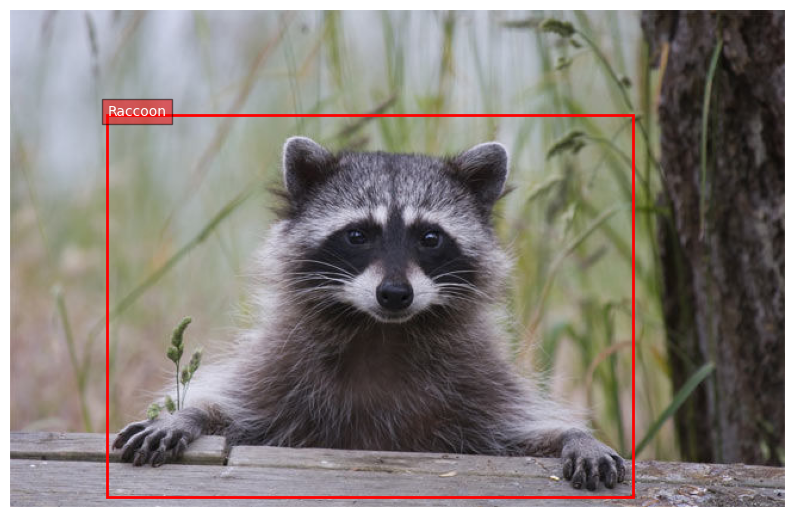

In [ ]:
# 1. 實體化 Dataset
dataset = RaccoonDataset(root_dir='raccoon_dataset', transforms=get_test_transform())
print(f"Dataset 準備就緒，共有 {len(dataset)} 筆資料。")

# 2. 取出第 0 張圖片與標註
img_tensor, target = dataset[0]

# 3. 定義繪圖函式
def plot_img_bbox(img_tensor, target):
    # 將 Tensor 維度轉換為 Matplotlib 需要的格式
    img = img_tensor.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # 畫出所有標註框
    for box in target['boxes']:
        # 轉為 numpy array
        xmin, ymin, xmax, ymax = box.numpy()

        # 轉換座標格式並算出寬高
        width = xmax - xmin
        height = ymax - ymin

        # 建立紅色矩形框
        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor='r',
            facecolor='none'
        )
        ax.add_patch(rect)
        # 加上文字標籤
        ax.text(xmin, ymin, 'Raccoon', color='white',
                bbox=dict(facecolor='red', alpha=0.5))

    plt.axis('off')
    plt.show()

# 繪圖
print("顯示第 0 張圖片驗證結果：")
plot_img_bbox(img_tensor, target)

### 建立 Faster R-CNN 模型
此區塊載入預訓練的 `Faster R-CNN (ResNet50 FPN)` 模型，並執行「微調（Fine-tuning）」的關鍵步驟。
由於原始模型是針對 COCO 91 類別訓練的，程式會將模型的分類頭（Box Predictor）替換掉，建立一個新的分類層以適應我們的任務（僅需預測「背景」與「浣熊」共 2 類）。

In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model_instance_segmentation(num_classes):
    """
    建立一個 Faster R-CNN 模型，並針對特定類別數量進行微調
    Args:
        num_classes (int): 包含背景在內的總類別數
    """
    # # 1. 載入預訓練模型 (COCO weights)

    # model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

    # 2. 取得分類器的輸入特徵數 (Input Features)
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # 3. 替換預測頭 (Head)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# --- 模型架構 ---
# Raccoon 資料集
num_classes = 2
model = get_model_instance_segmentation(num_classes)

print("模型建立成功！")
print(f"分類頭輸入特徵數: {model.roi_heads.box_predictor.cls_score.in_features}")
print(f"分類頭輸出類別數: {model.roi_heads.box_predictor.cls_score.out_features} (預期應為 2)")

模型建立成功！
分類頭輸入特徵數: 1024
分類頭輸出類別數: 2 (預期應為 2)


### 早停機制 (Early Stopping)
為了避免模型過度擬合 (Overfitting) 並節省訓練時間，這裡定義了 `EarlyStopping` 類別。
邏輯如下：
* 監控 **Validation Loss**。
* 若 Loss 在連續 `patience` 個回合內沒有下降，系統將自動中斷訓練。
* 每次 Loss 創新低時，程式會自動儲存當前的最佳模型權重。

In [25]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, path='best_model.pt'):
        self.patience = patience    # 容忍次數
        self.delta = delta       # 最小改善幅度
        self.path = path        # 模型儲存路徑
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        # 1. 第一輪：直接初始化
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        # 2. 判斷是否有進步
        elif val_loss < self.best_loss - self.delta:
            # 有進步：儲存模型，重置計數器
            self.save_checkpoint(val_loss, model)
            self.best_loss = val_loss # 存完檔再更新最佳值，這樣 Log 才準
            self.counter = 0
        # 3. 沒進步
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter > self.patience:
                self.early_stop = True

    def save_checkpoint(self, val_loss, model):
        # 儲存模型權重
        print(f'Validation loss decreased ({self.best_loss:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)

### 設定優化器與排程器
此區塊設定訓練的核心參數：
1.  **裝置設定**：將模型移動至 GPU 進行加速。
2.  **優化器 (Optimizer)**：使用 SGD (隨機梯度下降) 更新參數，並設定動量 (Momentum) 與權重衰減 (Weight Decay)。
3.  **排程器 (Scheduler)**：使用 `StepLR`，讓學習率隨著訓練進行而遞減，幫助模型在後期收斂得更穩定。

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

# --- 準備工作 ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# 1. 設定優化器
# params = [p for p in model.parameters() if p.requires_grad]

# # 程式凍結骨幹網路 (Backbone)
# for param in model.backbone.parameters():
#     param.requires_grad = False

# 2. 確認哪些部分是可以訓練的
trainable_params = [p for p in model.parameters() if p.requires_grad]

print(f"總參數數量: {len(list(model.parameters()))}")
print(f"需訓練參數數量 (凍結後): {len(trainable_params)}")

# 3. 程式設定優化器
optimizer = torch.optim.SGD(
    trainable_params,
    lr=0.005,           # 學習率
    momentum=0.9,       # 動量
    weight_decay=0.0005 # 權重衰減 (Regularization)
)

# 2. 設定 Scheduler (每 3 個 Epoch，LR 乘以 0.9)
# 這樣模型後期會學得比較細膩
scheduler = StepLR(optimizer, step_size=3, gamma=0.9)

# 3. 初始化 Early Stopping (耐心設為 3，表示連 3 次沒進步就停)
early_stopping = EarlyStopping(patience=3, delta=0.001)

print(f"訓練環境設置完成！")
print(f"使用裝置: {device}")
print(f"優化器: SGD (lr=0.005)")

### 9. 下載輔助工具程式
為了進行標準的 COCO 指標評估（如 mAP），程式需要 PyTorch 官方提供的一些輔助腳本（例如 `engine.py`, `coco_eval.py`）。

In [ ]:
import os
import urllib.request

# 檔案下載網址 (對應 PyTorch 官方倉庫)
base_url = "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/"
files_to_download = [
    "engine.py",
    "utils.py",
    "coco_utils.py",
    "coco_eval.py",
    "transforms.py"
]

print("正在下載必要的輔助檔案...")

for file_name in files_to_download:
    url = base_url + file_name
    if not os.path.exists(file_name):
        try:
            print(f"正在下載 {file_name} ...")
            urllib.request.urlretrieve(url, file_name)
            print(f"{file_name} 下載成功")
        except Exception as e:
            print(f"{file_name} 下載失敗: {e}")
    else:
        print(f"{file_name} 已存在，跳過下載")

print("下載完成！現在您可以 import engine 了。")

### 10. 定義 COCO 評估函式
這是一個客製化的評估區塊。
由於直接使用官方腳本有時會遇到資料格式不相容的問題，這裡定義了：
1.  `get_coco_api_from_dataset_fixed`：負責將我們的 Dataset 物件轉換為 COCO API 標準格式。
2.  `my_evaluate`：在驗證階段呼叫，計算並輸出 **mAP (mean Average Precision)** 指標，用來量化模型的偵測準確度。

In [ ]:
import torch
import torch.utils.data
import math
import sys
import time
from coco_eval import CocoEvaluator
from pycocotools.coco import COCO
import contextlib
import io

# 1. 定義修復版的資料轉換函式
def get_coco_api_from_dataset_fixed(dataset):
    # 系統尋找原始 dataset (處理 Subset 包裝)
    for _ in range(10):
        if isinstance(dataset, torch.utils.data.Subset):
            dataset = dataset.dataset
            
    dataset_coco = []
    annotations = []
    ann_id = 1
    
    # 程式手動補上類別，解決 KeyError
    categories = [{"id": 1, "name": "raccoon"}]
        
    for img_idx in range(len(dataset)):
        img, targets = dataset[img_idx]
        image_id = targets["image_id"]
        
        # 系統強制轉型 ID
        if hasattr(image_id, 'item'): 
            image_id = image_id.item()
        image_id = int(image_id)
            
        img_dict = {}
        img_dict["id"] = image_id
        img_dict["height"] = img.shape[-2]
        img_dict["width"] = img.shape[-1]
        dataset_coco.append(img_dict)
        
        # 程式填寫 Annotations
        bboxes = targets["boxes"]
        labels = targets["labels"]
        # 預防性處理 area/iscrowd
        areas = targets["area"] if "area" in targets else torch.zeros(len(bboxes))
        iscrowd = targets["iscrowd"] if "iscrowd" in targets else torch.zeros(len(bboxes))

        for i in range(len(bboxes)):
            ann = {}
            ann["image_id"] = image_id
            ann["bbox"] = bboxes[i].tolist()
            ann["category_id"] = int(labels[i])
            ann["id"] = ann_id
            
            # 轉換框框格式 [x1, y1, x2, y2] -> [x, y, w, h]
            xmin, ymin, xmax, ymax = ann["bbox"]
            ann["bbox"] = [xmin, ymin, xmax - xmin, ymax - ymin]
            ann["area"] = float(areas[i]) if i < len(areas) else (xmax-xmin)*(ymax-ymin)
            ann["iscrowd"] = int(iscrowd[i]) if i < len(iscrowd) else 0
            
            annotations.append(ann)
            ann_id += 1

    # 程式封裝並回傳 COCO 物件
    coco_ds = COCO()
    coco_ds.dataset = {}
    coco_ds.dataset["images"] = dataset_coco
    coco_ds.dataset["annotations"] = annotations
    coco_ds.dataset["categories"] = categories 
    
    # 程式補上 info 和 licenses
    coco_ds.dataset["info"] = {"description": "Raccoon Dataset", "year": 2025}
    coco_ds.dataset["licenses"] = []
    
    coco_ds.createIndex()
    return coco_ds

# 2. 定義本地版 evaluate
@torch.inference_mode()
def my_evaluate(model, data_loader, device):
    model.eval()
    
    # 系統建立標準答案
    coco = get_coco_api_from_dataset_fixed(data_loader.dataset)
    
    # 初始化評分器
    coco_evaluator = CocoEvaluator(coco, ["bbox"])
    
    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            
        outputs = model(images)
        outputs = [{k: v.to(torch.device("cpu")) for k, v in t.items()} for t in outputs]

        res = {}
        for target, output in zip(targets, outputs):
            # 確保預測結果的 ID 也是 Int
            image_id = target["image_id"]
            if hasattr(image_id, 'item'): 
                image_id = image_id.item()
            res[int(image_id)] = output
        
        coco_evaluator.update(res)

    # 計算並彙整結果
    coco_evaluator.synchronize_between_processes()
    coco_evaluator.accumulate()
    # coco_evaluator.summarize()

    # 隱藏過多資訊
    with contextlib.redirect_stdout(io.StringIO()):
        coco_evaluator.summarize()
    
    # 手動取出 mAP 分數
    stats = coco_evaluator.coco_eval['bbox'].stats
    mAP = stats[0]
    mAP50 = stats[1]
    
    print(f"Eval Result | mAP(50-95): {mAP:.4f} | mAP(50): {mAP50:.4f}")
    
    return coco_evaluator

### 主訓練迴圈 (Training Loop)
這是整個專案的核心。程式將迭代執行 20 個 Epoch。
每個 Epoch 包含兩個階段：
1.  **訓練階段 (Train)**：計算損失並更新模型參數。
2.  **驗證階段 (Validation)**：計算驗證損失並執行 mAP 評估。
最後，早停機制 (Early Stopping) 會監控驗證損失，若模型效能不再提升，系統將自動停止訓練並載入最佳權重。

In [ ]:
import time
from engine import evaluate

# 定義計算 Validation Loss 的輔助函式
def evaluate_loss(model, data_loader, device):
    # 保持 .train() 模式以取得 loss dict，但使用 torch.no_grad() 關閉梯度
    model.train()
    running_loss = 0.0

    with torch.no_grad():
        for images, targets in data_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            running_loss += losses.item()

    return running_loss / len(data_loader)

# --- 主訓練迴圈 ---
num_epochs = 20 
train_loss_history = []
val_loss_history = []
val_map_history = []

print("開始訓練 (含 Early Stopping & Scheduler)...")

for epoch in range(num_epochs):
    start_time = time.time()

    # A. 訓練階段 (Training)
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        running_loss += losses.item()

    train_loss = running_loss / len(train_loader)
    train_loss_history.append(train_loss)

    # B. 更新 Learning Rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # C. 驗證階段 (Validation)
    val_loss = evaluate_loss(model, test_loader, device)
    val_loss_history.append(val_loss)

    # 系統執行評估並取得結果
    coco_evaluator = my_evaluate(model, test_loader, device=device)

    # 程式從結果中取得 mAP 數值
    current_map = coco_evaluator.coco_eval['bbox'].stats[0]

    # 把分數存進清單
    val_map_history.append(current_map)

    # 顯示資訊
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} "
          f"| Time: {time.time() - start_time:.1f}s")

    # D. 檢查 Early Stopping
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("早停機制啟動！停止訓練。")
        break

# 訓練結束後，把「最佳模型」載入回來
model.load_state_dict(torch.load('best_model.pt'))
print("已載入 Validation Loss 最低的 最佳模型權重。")

### 成果預測與展示
訓練完成後，此區塊用於驗收模型成果。
1.  **推論 (Inference)**：程式將模型切換至 `eval` 模式，並從測試集隨機取出一張圖片進行預測。
2.  **結果過濾**：設定信心閾值 (Threshold)，系統只會保留信心分數夠高的預測框。
3.  **視覺化**：將圖片與預測結果繪製出來，檢查模型是否能準確框出浣熊。

Top 5 預測分數: [0.9892039]
顯示預測結果...


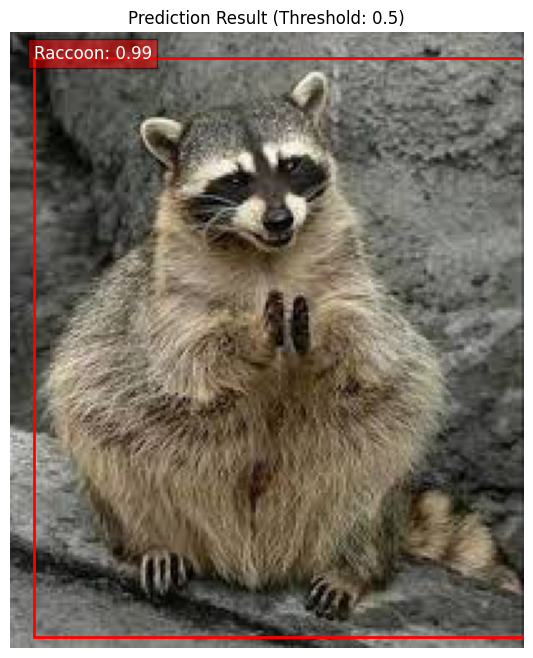

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. 切換到評估模式
model.eval()

# 2. 從測試集拿一張圖
img_tensor, target = test_dataset[0]

# 3. 進行預測
# 把圖片加一個 batch 維度: (C, H, W) -> (1, C, H, W)並送入 GPU
with torch.no_grad():
    prediction = model([img_tensor.to(device)])

# 4. 取出預測結果
pred_boxes = prediction[0]['boxes'].cpu().numpy()
pred_scores = prediction[0]['scores'].cpu().numpy()

print(f"Top 5 預測分數: {pred_scores[:5]}")

# 5. 定義繪圖函式 (含分數過濾)
def plot_prediction(img_tensor, boxes, scores, threshold=0.5):
    img = img_tensor.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # 遍歷所有預測框
    for box, score in zip(boxes, scores):
        if score > threshold:  # 只畫信心度夠高的
            xmin, ymin, xmax, ymax = box
            width = xmax - xmin
            height = ymax - ymin

            # 畫紅框
            rect = patches.Rectangle(
                (xmin, ymin),
                width,
                height,
                linewidth=2,
                edgecolor='r',
                facecolor='none'
            )
            ax.add_patch(rect)

            # 標示分數
            ax.text(xmin, ymin, f'Raccoon: {score:.2f}',
                    color='white', fontsize=12,
                    bbox=dict(facecolor='red', alpha=0.5))

    plt.axis('off')
    plt.title(f"Prediction Result (Threshold: {threshold})")
    plt.show()

# 執行繪圖
print("顯示預測結果...")
plot_prediction(img_tensor, pred_boxes, pred_scores, threshold=0.5)

### 輸出最佳模型數據 (Best Model Metrics)

此區塊用於從訓練歷史中提取最佳模型的詳細指標：
1.  **定位最佳點**：系統會在 `val_loss_history` 中尋找數值最小的索引 (Index)，這代表 Early Stopping 判定為「最佳」的那個 Epoch。
2.  **提取對應數據**：根據該索引，程式從 `train_loss_history` 與 `val_map_history` 中取出對應的數值。
3.  **結果展示**：印出該模型是在第幾個 Epoch 被選定，以及當時的 Loss 與 mAP。

In [ ]:
import numpy as np

# 1. 找出 Validation Loss 最低的索引 (即最佳模型存檔點)
best_val_loss = min(val_loss_history)
best_epoch_index = val_loss_history.index(best_val_loss)

# 2. 根據索引提取對應的其他指標
best_train_loss = train_loss_history[best_epoch_index]
best_map = val_map_history[best_epoch_index]

best_epoch_num = best_epoch_index + 1

# 3. 程式格式化輸出結果
print("="*30)
print(f"🏆 最終選定模型 (Best Model) 資訊")
print("="*30)
print(f"選定 Epoch:  {best_epoch_num}")
print(f"Train Loss:  {best_train_loss:.4f}")
print(f"Val Loss:    {best_val_loss:.4f}  (最小值)")
print(f"mAP (50-95): {best_map:.4f}")
print("="*30)

🏆 最終選定模型 (Best Model) 資訊
選定 Epoch:  8
Train Loss:  0.2599
Val Loss:    0.2339  (最小值)
mAP (50-95): 0.7218


### 繪製訓練過程與成效分析圖表 (Training Metrics Visualization)

此區塊利用 Matplotlib 將訓練迴圈中收集到的數據 (`loss_history`, `map_history`) 繪製成折線圖。
圖表分為左右兩部分：
* **左圖 (Loss Curve)**：比較訓練損失 (Train Loss) 與驗證損失 (Val Loss)。
* **右圖 (mAP Accuracy)**：顯示驗證集的 mAP (mean Average Precision) 分數。

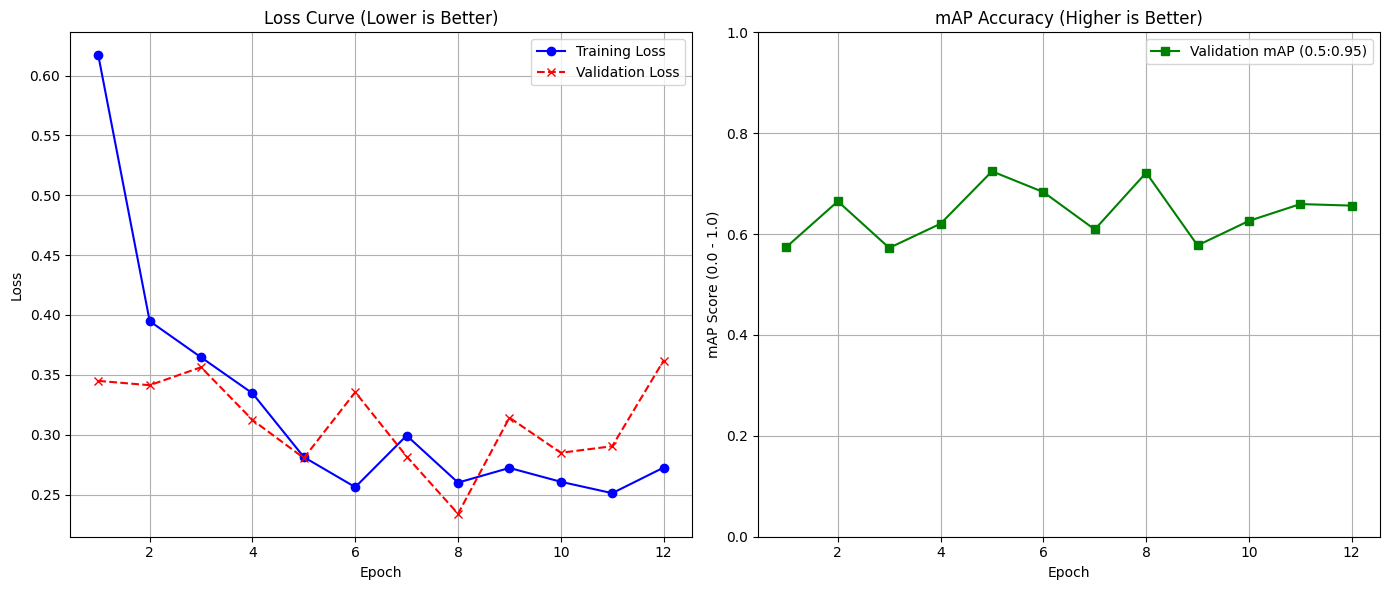

In [ ]:
import matplotlib.pyplot as plt

# --- 繪製訓練結果圖表 ---
epochs_range = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(14, 6)) # 設定畫布大小 (寬, 高)

# --- 左圖：Loss 曲線 ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss_history, label='Validation Loss', marker='x', color='red', linestyle='--')
plt.title('Loss Curve (Lower is Better)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# --- 右圖：mAP 準確率曲線 ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_map_history, label='Validation mAP (0.5:0.95)', marker='s', color='green')
plt.title('mAP Accuracy (Higher is Better)')
plt.xlabel('Epoch')
plt.ylabel('mAP Score (0.0 - 1.0)')
plt.ylim(0, 1.0) # 設定 Y 軸範圍在 0 到 1 之間
plt.grid(True)
plt.legend()

plt.tight_layout() # 自動調整間距，避免文字重疊
plt.show()

### 混淆矩陣與效能指標評估

此區塊是用來深入分析模型效能的關鍵步驟。不同於 mAP 只有一個分數，這裡我們計算具體的 **混淆矩陣 (Confusion Matrix)** 以了解模型的行為模式。

程式執行流程如下：
1.  **定義評估邏輯**：透過 `calculate_confusion_matrix` 函式，設定信心門檻 (Score Threshold) 與重疊門檻 (IoU Threshold) 來判定預測是否正確。
2.  **統計三類指標**：
    * **TP (True Positive)**：模型正確偵測到浣熊。
    * **FP (False Positive)**：模型誤報 (將背景誤判為浣熊，或 IoU 不夠高)。
    * **FN (False Negative)**：模型漏抓 (沒偵測到存在的浣熊)。
3.  **視覺化與計算**：利用 `Seaborn` 繪製熱力圖，並進一步計算 **Precision (精確率)**、**Recall (召回率)** 與 **F1 Score**。

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

def calculate_confusion_matrix(model, data_loader, device, score_threshold=0.5, iou_threshold=0.5):
    model.eval()

    # 初始化計數器
    TP = 0  # 抓對浣熊
    FP = 0  # 把背景當浣熊 (誤報)
    FN = 0  # 沒抓到浣熊 (漏抓)

    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for i, output in enumerate(outputs):
                target_boxes = targets[i]['boxes'].to(device)

                # 1. 篩選信心分數 (Score > Threshold)
                pred_scores = output['scores']
                mask = pred_scores > score_threshold
                pred_boxes = output['boxes'][mask]

                # 如果這張圖完全沒有預測出任何框
                if len(pred_boxes) == 0:
                    FN += len(target_boxes) # 所有的真實框都漏掉了
                    continue

                # 如果這張圖原本就沒有浣熊
                if len(target_boxes) == 0:
                    FP += len(pred_boxes) # 所有的預測都是誤報
                    continue

                # 2. 計算 IoU (Intersection over Union)
                # iou_matrix 形狀: [預測框數, 真實框數]
                iou_matrix = torchvision.ops.box_iou(pred_boxes, target_boxes)

                # 3. 進行配對 (Matching)
                # 找出每個預測框對應到最大的真實框 IoU
                max_iou_values, max_iou_indices = torch.max(iou_matrix, dim=1)

                # 紀錄哪些真實框已經被配對過了 (避免重複算TP)
                gt_matched = set()

                for pred_idx, iou in enumerate(max_iou_values):
                    if iou > iou_threshold:
                        gt_idx = max_iou_indices[pred_idx].item()
                        if gt_idx not in gt_matched:
                            TP += 1
                            gt_matched.add(gt_idx)
                        else:
                            FP += 1 # 重複抓算 FP
                    else:
                        FP += 1 # IoU 太低，算誤報

                # 4. 計算漏抓 (FN)
                # 該張圖總共有多少浣熊 - 被成功配對的數量
                FN += len(target_boxes) - len(gt_matched)

    return TP, FP, FN

# --- 執行計算 ---
print("正在計算混淆矩陣數據...")
tp, fp, fn = calculate_confusion_matrix(model, test_loader, device)

print(f"統計結果:")
print(f" - TP (抓對): {tp}")
print(f" - FP (誤報): {fp}")
print(f" - FN (漏抓): {fn}")

# --- 繪製混淆矩陣圖 ---
# [TP, FN] -> 真的有浣熊 (被抓到, 被漏掉)
# [FP, 0 ] -> 真的沒浣熊 (被誤抓, 正確忽略)

matrix_data = np.array([
    [tp, fn],
    [fp, 0]
])

labels = ['Raccoon', 'Background']

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Raccoon', 'Pred: Background'],
            yticklabels=['Actual: Raccoon', 'Actual: Background'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix (Object Detection)')
plt.show()

# 計算 Precision 與 Recall
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision (準確率 - 抓到的有多少是真的): {precision:.2%}")
print(f"Recall    (召回率 - 真的有多少被抓出來): {recall:.2%}")
print(f"F1 Score  (綜合指標): {f1_score:.2f}")